# Chapter 27 Python Lab  
## Review, Synthesis, and Bridge to Graduate Study

This lab accompanies **Chapter 27: Review, Synthesis, and Bridge to Graduate Study**.

This final lab is a synthesis lab. It brings together the main computational ideas from multivariable calculus:

- geometry of vectors, planes, curves, and surfaces;
- scalar fields, level sets, gradients, and Hessians;
- Taylor approximation and local models;
- optimization and constrained optimization;
- double, triple, and surface integrals;
- coordinate changes and Jacobians;
- vector fields, line integrals, flux, curl, divergence;
- Green's theorem, Stokes' theorem, and the divergence theorem;
- probability, statistics, machine learning, and applied mathematics.

The goal is not to introduce many new formulas.  
The goal is to build a computational review framework that helps you see the unity of the course.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. organize the main ideas of multivariable calculus into a connected map;
2. compute gradients, Hessians, Jacobians, divergence, curl, and Laplacians numerically;
3. connect local approximation with optimization;
4. connect integrals with accumulated quantity, probability, mass, and flux;
5. verify simple forms of Green's theorem, Stokes' theorem, and the divergence theorem;
6. use multivariable calculus ideas in probability, data science, and applied modeling;
7. identify which later graduate topics grow out of each calculus idea;
8. complete a small capstone synthesis project.

## Source note

This notebook was generated from the uploaded Chapter 27 QMD file.  
The extracted early headings from the source file include:

- Learning goals
- The central habit
- 27.1 The big map of the subject
- 27.2 Geometry: the coordinate language
- Example 27.1: Projection as a least-squares approximation
- 27.3 Derivatives: local change and local models
- Example 27.2: Local quadratic geometry
- 27.4 Jacobians: derivatives of vector-valued maps
- Example 27.3: The polar-coordinate Jacobian
- 27.5 Integrals: accumulation over geometric objects
- Example 27.4: Probability as a double integral
- 27.6 Optimization: from critical points to algorithms
- 27.7 Vector fields and the global theorems
- The four Fundamental-Theorem patterns
- 27.8 A problem-solving decision tree
- 27.9 A compact formula sheet with meaning

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.max_open_warning"] = 120
norm = np.linalg.norm

def make_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=250):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def midpoint_grid(xmin, xmax, ymin, ymax, nx=300, ny=300):
    dx = (xmax-xmin)/nx
    dy = (ymax-ymin)/ny
    x = xmin + (np.arange(nx)+0.5)*dx
    y = ymin + (np.arange(ny)+0.5)*dy
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y, dx, dy

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def integrate_rect(f, xmin, xmax, ymin, ymax, nx=400, ny=400):
    x, y, X, Y, dx, dy = midpoint_grid(xmin, xmax, ymin, ymax, nx=nx, ny=ny)
    Z = safe_eval_2d(f, X, Y)
    return float(np.sum(Z)*dx*dy), X, Y, Z, dx, dy

def integrate_region(f, xmin, xmax, ymin, ymax, mask, nx=400, ny=400):
    x, y, X, Y, dx, dy = midpoint_grid(xmin, xmax, ymin, ymax, nx=nx, ny=ny)
    Z = safe_eval_2d(f, X, Y)
    inside = mask(X, Y)
    return float(np.sum(Z[inside])*dx*dy), X, Y, Z, inside, dx, dy

def finite_gradient(f, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    g = np.zeros_like(p)
    for j in range(len(p)):
        e = np.zeros_like(p)
        e[j] = h
        g[j] = (f(p+e) - f(p-e))/(2*h)
    return g

def finite_hessian(f, p, h=1e-4):
    p = np.asarray(p, dtype=float)
    n = len(p)
    H = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ej = np.zeros(n)
            ei[i] = h; ej[j] = h
            H[i,j] = (f(p+ei+ej) - f(p+ei-ej) - f(p-ei+ej) + f(p-ei-ej))/(4*h*h)
    return H

def finite_jacobian(F, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    f0 = np.asarray(F(p), dtype=float)
    J = np.zeros((len(f0), len(p)))
    for j in range(len(p)):
        e = np.zeros_like(p)
        e[j] = h
        J[:,j] = (np.asarray(F(p+e)) - np.asarray(F(p-e)))/(2*h)
    return J

def finite_gradient_grid(U, dx, dy):
    Uy, Ux = np.gradient(U, dy, dx, edge_order=2)
    return Ux, Uy

def finite_divergence_grid(P, Q, dx, dy):
    Qy, _ = np.gradient(Q, dy, dx, edge_order=2)
    _, Px = np.gradient(P, dy, dx, edge_order=2)
    return Px + Qy

def finite_laplacian_grid(U, dx, dy):
    Ux, Uy = finite_gradient_grid(U, dx, dy)
    return finite_divergence_grid(Ux, Uy, dx, dy)

def numerical_scalar_curl_2d(Pfun, Qfun, X, Y, h=1e-5):
    Qx = (Qfun(X+h, Y) - Qfun(X-h, Y))/(2*h)
    Py = (Pfun(X, Y+h) - Pfun(X, Y-h))/(2*h)
    return Qx - Py

def line_integral_2d(F, r, rp, a, b, n=4000):
    t = np.linspace(a, b, n)
    X, Y = r(t)
    dX, dY = rp(t)
    P, Q = F(X, Y)
    integrand = P*dX + Q*dY
    return float(np.trapezoid(integrand, t)), t, X, Y, integrand

def arc_length_2d(rp, a, b, n=4000):
    t = np.linspace(a, b, n)
    dX, dY = rp(t)
    speed = np.sqrt(dX**2 + dY**2)
    return float(np.trapezoid(speed, t)), t, speed

def make_3d_axes(title=None, elev=25, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def plot_contours(f, xmin=-3, xmax=3, ymin=-3, ymax=3, n=300, levels=24, title="Contours"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    plt.figure(figsize=(7, 6))
    cs = plt.contour(X, Y, Z, levels=levels)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def plot_surface(f, xmin=-3, xmax=3, ymin=-3, ymax=3, n=120, title="Surface"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    fig, ax = make_3d_axes(title=title)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.8)
    plt.show()
    return X, Y, Z

def plot_vector_field(F, xmin=-3, xmax=3, ymin=-3, ymax=3, n=23, normalize=True, title="Vector field"):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    U, V = F(X, Y)
    M = np.sqrt(U**2 + V**2)
    if normalize:
        Uplot = U/(M+1e-12)
        Vplot = V/(M+1e-12)
    else:
        Uplot, Vplot = U, V
    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, Uplot, Vplot, M)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, U, V, M

def rk4_solve(F, x0, t0=0, t1=10, dt=0.01):
    steps = int(np.ceil((t1-t0)/dt))
    t = t0 + np.arange(steps+1)*dt
    X = np.zeros((steps+1, len(x0)))
    X[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        h = dt
        tk = t[k]
        xk = X[k]
        k1 = np.asarray(F(tk, xk), dtype=float)
        k2 = np.asarray(F(tk+h/2, xk+h*k1/2), dtype=float)
        k3 = np.asarray(F(tk+h/2, xk+h*k2/2), dtype=float)
        k4 = np.asarray(F(tk+h, xk+h*k3), dtype=float)
        X[k+1] = xk + h*(k1+2*k2+2*k3+k4)/6
    return t, X

def gradient_descent(f, grad, start, step_size=0.1, steps=100):
    theta = np.asarray(start, dtype=float)
    path = [theta.copy()]
    vals = [f(theta)]
    for k in range(steps):
        theta = theta - step_size*grad(theta)
        path.append(theta.copy())
        vals.append(f(theta))
    return np.array(path), np.array(vals)

def sigmoid(z):
    return 1/(1+np.exp(-z))

def covariance_ellipse_points(mu, Sigma, level=1.0, n=400):
    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    A = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0)))
    pts = np.asarray(mu)[:,None] + level*(A @ circle)
    return pts[0], pts[1]

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-5jqp5wgn because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. A concept map for the course

Multivariable calculus is not a list of disconnected techniques.  
Most topics fit into a small number of ideas:

1. **Objects**: points, vectors, curves, surfaces, scalar fields, vector fields.
2. **Local change**: derivative, gradient, Jacobian, Hessian, divergence, curl.
3. **Approximation**: tangent line, tangent plane, linearization, Taylor polynomial.
4. **Accumulation**: line, double, triple, and surface integrals.
5. **Transformation**: coordinate changes and Jacobians.
6. **Global theorems**: Green, Stokes, divergence theorem.
7. **Applications**: optimization, probability, machine learning, dynamics, PDEs.

## 1. Draw a course concept map

This is a visual index of the subject.

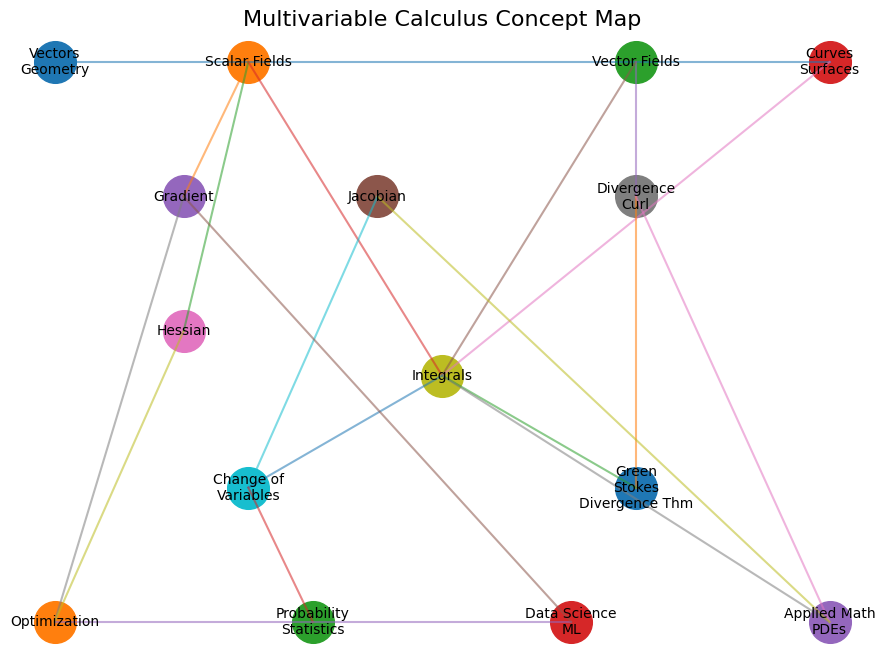

In [2]:
nodes = {
    "Vectors\nGeometry": (-3, 2),
    "Scalar Fields": (-1.5, 2),
    "Vector Fields": (1.5, 2),
    "Curves\nSurfaces": (3, 2),
    "Gradient": (-2, 0.8),
    "Jacobian": (-0.5, 0.8),
    "Hessian": (-2, -0.4),
    "Divergence\nCurl": (1.5, 0.8),
    "Integrals": (0, -0.8),
    "Change of\nVariables": (-1.5, -1.8),
    "Green\nStokes\nDivergence Thm": (1.5, -1.8),
    "Optimization": (-3, -3),
    "Probability\nStatistics": (-1, -3),
    "Data Science\nML": (1, -3),
    "Applied Math\nPDEs": (3, -3),
}

edges = [
    ("Vectors\nGeometry", "Curves\nSurfaces"),
    ("Scalar Fields", "Gradient"),
    ("Scalar Fields", "Hessian"),
    ("Scalar Fields", "Integrals"),
    ("Vector Fields", "Divergence\nCurl"),
    ("Vector Fields", "Integrals"),
    ("Curves\nSurfaces", "Integrals"),
    ("Gradient", "Optimization"),
    ("Hessian", "Optimization"),
    ("Jacobian", "Change of\nVariables"),
    ("Integrals", "Change of\nVariables"),
    ("Divergence\nCurl", "Green\nStokes\nDivergence Thm"),
    ("Integrals", "Green\nStokes\nDivergence Thm"),
    ("Change of\nVariables", "Probability\nStatistics"),
    ("Optimization", "Data Science\nML"),
    ("Gradient", "Data Science\nML"),
    ("Divergence\nCurl", "Applied Math\nPDEs"),
    ("Integrals", "Applied Math\nPDEs"),
    ("Jacobian", "Applied Math\nPDEs"),
]

plt.figure(figsize=(11, 8))
for a, b in edges:
    x1, y1 = nodes[a]
    x2, y2 = nodes[b]
    plt.plot([x1, x2], [y1, y2], linewidth=1.5, alpha=0.55)
for name, (x, y) in nodes.items():
    plt.scatter([x], [y], s=900)
    plt.text(x, y, name, ha="center", va="center", fontsize=10)
plt.axis("off")
plt.title("Multivariable Calculus Concept Map", fontsize=16)
plt.show()

---

# Part II. Local calculus synthesis: gradient, Hessian, Taylor approximation

Let

$$
f(x,y)=e^{-0.4(x^2+y^2)}+0.15x^2-0.1xy+0.2y.
$$

This single scalar field lets us review:

- surfaces and contours;
- gradients;
- Hessians;
- directional derivatives;
- Taylor approximations;
- critical points and optimization.

## 2. Visualize a scalar field

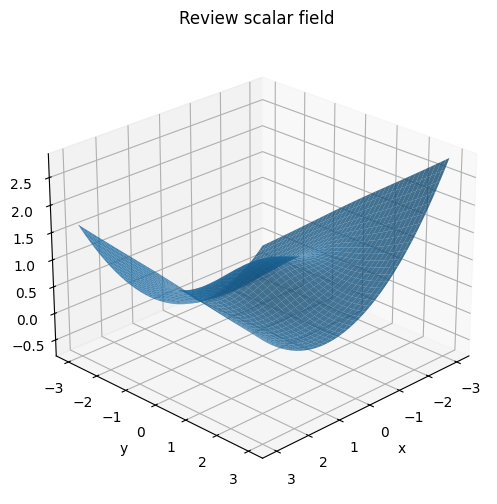

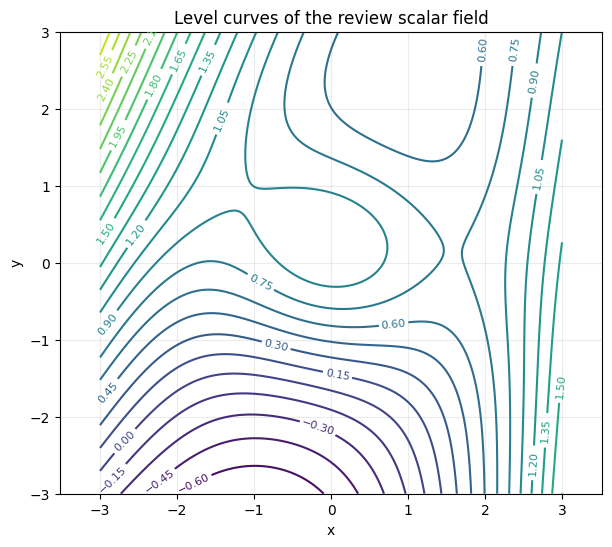

(array([[-3.      , -2.979933, -2.959866, ...,  2.959866,  2.979933,
          3.      ],
        [-3.      , -2.979933, -2.959866, ...,  2.959866,  2.979933,
          3.      ],
        [-3.      , -2.979933, -2.959866, ...,  2.959866,  2.979933,
          3.      ],
        ...,
        [-3.      , -2.979933, -2.959866, ...,  2.959866,  2.979933,
          3.      ],
        [-3.      , -2.979933, -2.959866, ...,  2.959866,  2.979933,
          3.      ],
        [-3.      , -2.979933, -2.959866, ...,  2.959866,  2.979933,
          3.      ]], shape=(300, 300)),
 array([[-3.      , -3.      , -3.      , ..., -3.      , -3.      ,
         -3.      ],
        [-2.979933, -2.979933, -2.979933, ..., -2.979933, -2.979933,
         -2.979933],
        [-2.959866, -2.959866, -2.959866, ..., -2.959866, -2.959866,
         -2.959866],
        ...,
        [ 2.959866,  2.959866,  2.959866, ...,  2.959866,  2.959866,
          2.959866],
        [ 2.979933,  2.979933,  2.979933, ...,  2.9799

In [3]:
def f_review_xy(X, Y):
    return np.exp(-0.4*(X**2 + Y**2)) + 0.15*X**2 - 0.1*X*Y + 0.2*Y

def f_review_p(p):
    x, y = p
    return float(f_review_xy(x, y))

plot_surface(f_review_xy, -3, 3, -3, 3, title="Review scalar field")
plot_contours(f_review_xy, -3, 3, -3, 3, levels=28, title="Level curves of the review scalar field")

## 3. Numerical gradient and Hessian at a point

In [4]:
p0 = np.array([0.8, -0.6])
g0 = finite_gradient(f_review_p, p0)
H0 = finite_hessian(f_review_p, p0)

eigvals, eigvecs = np.linalg.eigh(H0)

print("Base point:", p0)
print("f(p0):", f_review_p(p0))
print("Gradient:")
print(g0)
print("Hessian:")
print(H0)
print("Hessian eigenvalues:", eigvals)
print("Hessian eigenvectors as columns:")
print(eigvecs)

Base point: [ 0.8 -0.6]
f(p0): 0.6943200460356393
Gradient:
[-0.129005  0.441754]
Hessian:
[[ 0.038307 -0.305922]
 [-0.305922 -0.381814]]
Hessian eigenvalues: [-0.542852  0.199345]
Hessian eigenvectors as columns:
[[ 0.465805 -0.884887]
 [ 0.884887  0.465805]]


## 4. Tangent plane and quadratic Taylor model

The first-order model is

$$
T_1(p_0+h)=f(p_0)+\nabla f(p_0)\cdot h.
$$

The second-order model is

$$
T_2(p_0+h)=f(p_0)+\nabla f(p_0)\cdot h+\frac12 h^T H_f(p_0)h.
$$

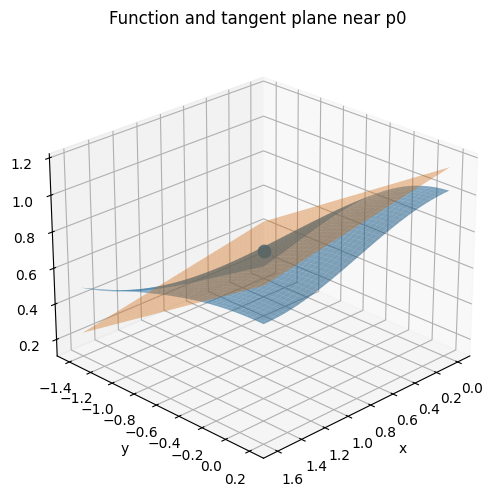

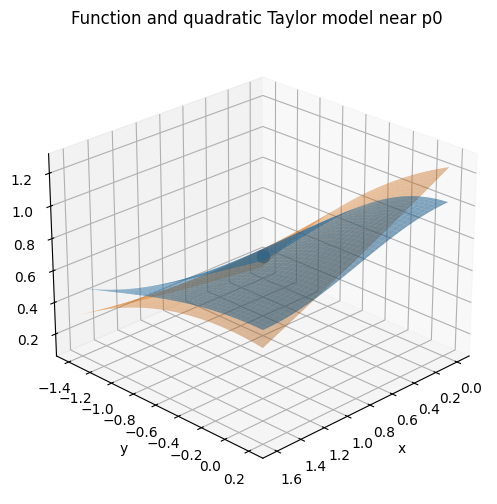

In [5]:
def T1_review(X, Y):
    U = X - p0[0]
    V = Y - p0[1]
    return f_review_p(p0) + g0[0]*U + g0[1]*V

def T2_review(X, Y):
    U = X - p0[0]
    V = Y - p0[1]
    return T1_review(X, Y) + 0.5*(H0[0,0]*U**2 + 2*H0[0,1]*U*V + H0[1,1]*V**2)

x, y, X, Y = make_grid(p0[0]-0.8, p0[0]+0.8, p0[1]-0.8, p0[1]+0.8, n=120)
Z = f_review_xy(X, Y)
Z1 = T1_review(X, Y)
Z2 = T2_review(X, Y)

fig, ax = make_3d_axes(title="Function and tangent plane near p0")
ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.55)
ax.plot_surface(X, Y, Z1, linewidth=0, alpha=0.40)
ax.scatter([p0[0]], [p0[1]], [f_review_p(p0)], s=80)
plt.show()

fig, ax = make_3d_axes(title="Function and quadratic Taylor model near p0")
ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.55)
ax.plot_surface(X, Y, Z2, linewidth=0, alpha=0.40)
ax.scatter([p0[0]], [p0[1]], [f_review_p(p0)], s=80)
plt.show()

## 5. Taylor error scaling

For a smooth function:

- first-order error is typically $O(r^2)$;
- second-order error is typically $O(r^3)$.

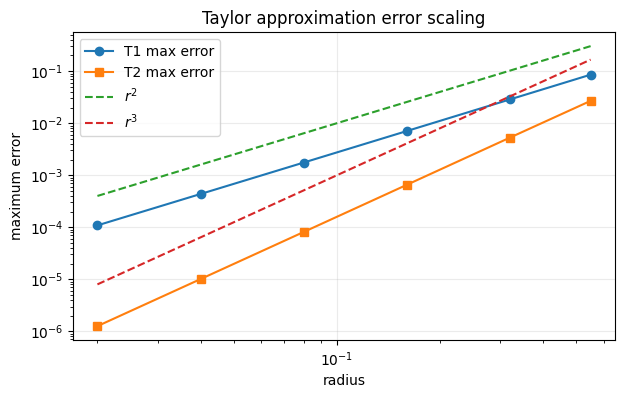

In [6]:
radii = np.array([0.02, 0.04, 0.08, 0.16, 0.32, 0.55])
theta = np.linspace(0, 2*np.pi, 1000, endpoint=False)

err1 = []
err2 = []
for r in radii:
    Xc = p0[0] + r*np.cos(theta)
    Yc = p0[1] + r*np.sin(theta)
    true = f_review_xy(Xc, Yc)
    err1.append(np.max(np.abs(true - T1_review(Xc, Yc))))
    err2.append(np.max(np.abs(true - T2_review(Xc, Yc))))

plt.figure(figsize=(7, 4))
plt.loglog(radii, err1, marker="o", label="T1 max error")
plt.loglog(radii, err2, marker="s", label="T2 max error")
plt.loglog(radii, radii**2, linestyle="--", label=r"$r^2$")
plt.loglog(radii, radii**3, linestyle="--", label=r"$r^3$")
plt.xlabel("radius")
plt.ylabel("maximum error")
plt.title("Taylor approximation error scaling")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part III. Optimization synthesis

Optimization asks for points where the gradient vanishes or where a constrained derivative condition holds.

For unconstrained optimization,

$$
\nabla f(p)=0.
$$

The Hessian classifies local shape:

- positive definite: local minimum;
- negative definite: local maximum;
- indefinite: saddle point.

## 6. Gradient descent on the review scalar field

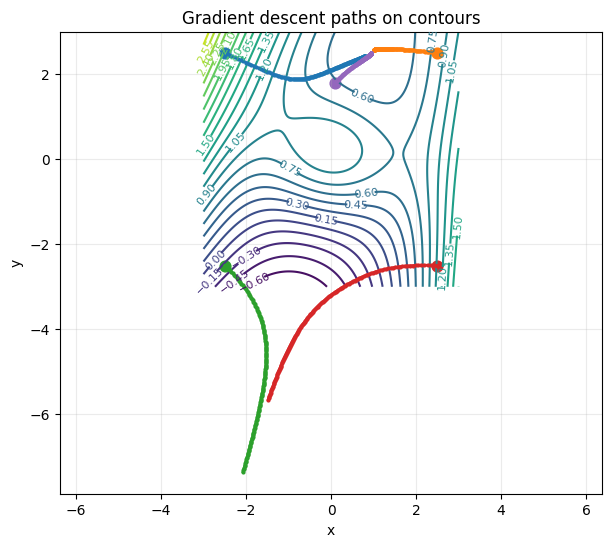

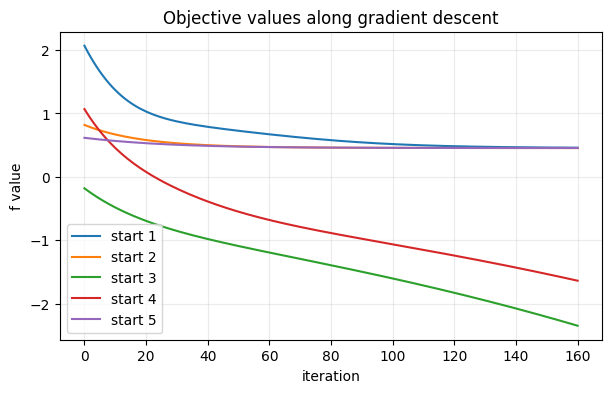

start 1, final point [0.80353  2.429698], final value 0.460384
start 2, final point [1.015414 2.578898], final value 0.454870
start 3, final point [-2.068963 -7.350336], final value -2.348733
start 4, final point [-1.479446 -5.652676], final value -1.638503
start 5, final point [0.951372 2.498775], final value 0.455087


In [7]:
def grad_review_p(p):
    return finite_gradient(f_review_p, p)

starts = [
    np.array([-2.5, 2.5]),
    np.array([2.5, 2.5]),
    np.array([-2.5, -2.5]),
    np.array([2.5, -2.5]),
    np.array([0.1, 1.8])
]

paths = []
values = []
for s in starts:
    path, vals = gradient_descent(f_review_p, grad_review_p, s, step_size=0.08, steps=160)
    paths.append(path)
    values.append(vals)

x, y, X, Y = make_grid(-3, 3, -3, 3, n=350)
Z = f_review_xy(X, Y)

plt.figure(figsize=(7, 6))
cs = plt.contour(X, Y, Z, levels=30)
plt.clabel(cs, inline=True, fontsize=8)
for path in paths:
    plt.plot(path[:,0], path[:,1], marker="o", markersize=2, linewidth=2)
    plt.scatter([path[0,0]], [path[0,1]], s=60)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient descent paths on contours")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
for i, vals in enumerate(values):
    plt.plot(vals, label=f"start {i+1}")
plt.xlabel("iteration")
plt.ylabel("f value")
plt.title("Objective values along gradient descent")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

for i, path in enumerate(paths):
    print(f"start {i+1}, final point {path[-1]}, final value {f_review_p(path[-1]):.6f}")

## 7. Constrained optimization review

Maximize or minimize $f(x,y)$ on the circle

$$
x^2+y^2=1.
$$

Parametrize the circle by

$$
x=\cos t,\qquad y=\sin t.
$$

Then the constrained problem becomes a one-variable problem.

Approx constrained minimum point: [-0.188246 -0.982122] value: 0.4607230956444366
Approx constrained maximum point: [-0.723307  0.690527] value: 0.9368475902500135


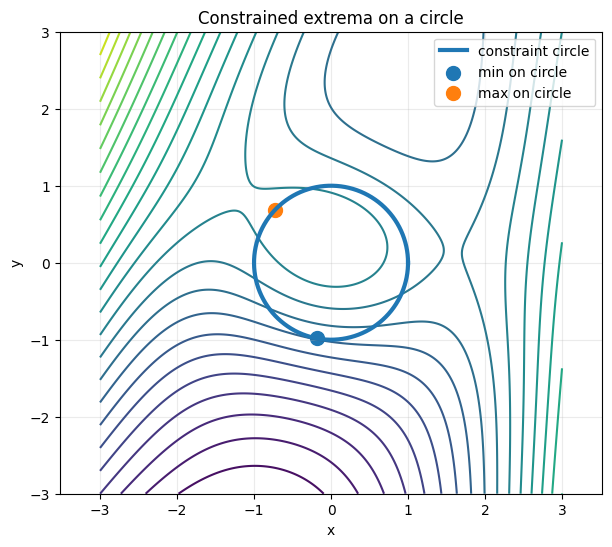

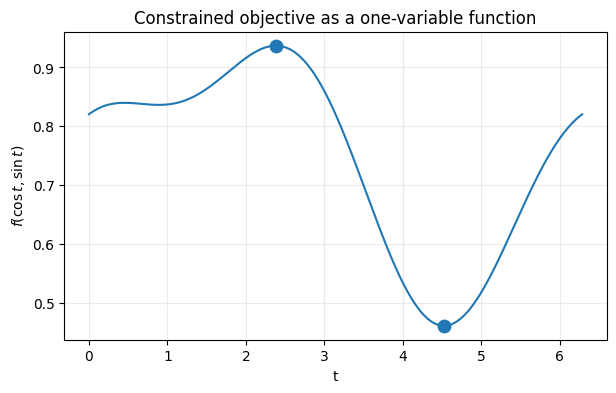

In [8]:
t = np.linspace(0, 2*np.pi, 2000)
xc = np.cos(t)
yc = np.sin(t)
vals_circle = f_review_xy(xc, yc)

i_min = np.argmin(vals_circle)
i_max = np.argmax(vals_circle)

p_min = np.array([xc[i_min], yc[i_min]])
p_max = np.array([xc[i_max], yc[i_max]])

print("Approx constrained minimum point:", p_min, "value:", vals_circle[i_min])
print("Approx constrained maximum point:", p_max, "value:", vals_circle[i_max])

plt.figure(figsize=(7, 6))
cs = plt.contour(X, Y, Z, levels=25)
plt.plot(xc, yc, linewidth=3, label="constraint circle")
plt.scatter([p_min[0]], [p_min[1]], s=100, label="min on circle")
plt.scatter([p_max[0]], [p_max[1]], s=100, label="max on circle")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Constrained extrema on a circle")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(t, vals_circle)
plt.scatter([t[i_min], t[i_max]], [vals_circle[i_min], vals_circle[i_max]], s=80)
plt.xlabel("t")
plt.ylabel(r"$f(\cos t,\sin t)$")
plt.title("Constrained objective as a one-variable function")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IV. Integral synthesis

Integrals are accumulation tools.

- $\int_C f\,ds$: accumulate over a curve.
- $\iint_D f\,dA$: accumulate over a region.
- $\iiint_E f\,dV$: accumulate over a solid.
- $\iint_S f\,dS$: accumulate over a surface.
- $\int_C \mathbf F\cdot d\mathbf r$: work/circulation.
- $\iint_S \mathbf F\cdot\mathbf n\,dS$: flux.

## 8. Area, mass, and center of mass on a region

Let $D$ be the unit disk and density

$$
\rho(x,y)=1+0.4x+0.2y^2.
$$

Compute mass and center of mass:

$$
M=\iint_D \rho\,dA,
$$

$$
\bar x=\frac1M\iint_D x\rho\,dA,
\qquad
\bar y=\frac1M\iint_D y\rho\,dA.
$$

Mass: 3.2987342397867563
Center of mass: [0.09524 0.     ]


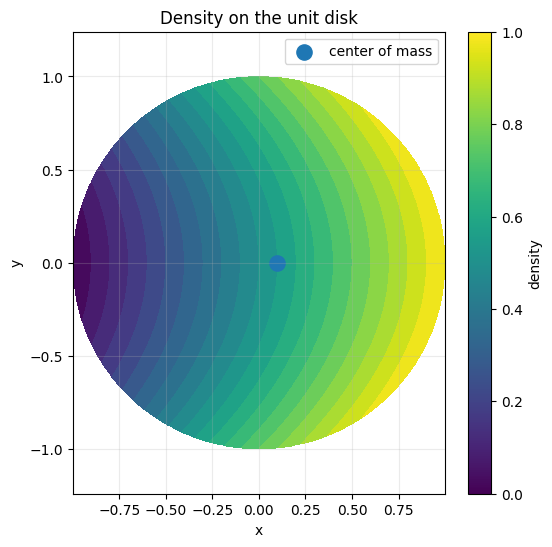

In [9]:
def rho_disk(X, Y):
    return 1 + 0.4*X + 0.2*Y**2

disk_mask = lambda X, Y: X**2 + Y**2 <= 1

M, Xd, Yd, Zrho, inside, dx, dy = integrate_region(rho_disk, -1, 1, -1, 1, disk_mask, nx=700, ny=700)
Mx, *_ = integrate_region(lambda X, Y: X*rho_disk(X, Y), -1, 1, -1, 1, disk_mask, nx=700, ny=700)
My, *_ = integrate_region(lambda X, Y: Y*rho_disk(X, Y), -1, 1, -1, 1, disk_mask, nx=700, ny=700)

center = np.array([Mx/M, My/M])

print("Mass:", M)
print("Center of mass:", center)

plt.figure(figsize=(6, 6))
plt.contourf(Xd, Yd, np.where(inside, Zrho, np.nan), levels=24)
plt.scatter([center[0]], [center[1]], s=120, label="center of mass")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Density on the unit disk")
plt.axis("equal")
plt.colorbar(label="density")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 9. Coordinate change review: polar integral

The disk integral can also be written in polar coordinates:

$$
x=r\cos\theta,\qquad y=r\sin\theta,
$$

with Jacobian factor $r$.

Thus

$$
M=\int_0^{2\pi}\int_0^1 \rho(r\cos\theta,r\sin\theta)r\,dr\,d\theta.
$$

In [10]:
r, theta, R, TH, dr, dtheta = midpoint_grid(0, 1, 0, 2*np.pi, nx=500, ny=700)
Xp = R*np.cos(TH)
Yp = R*np.sin(TH)
polar_integrand = rho_disk(Xp, Yp)*R
M_polar = np.sum(polar_integrand)*dr*dtheta

print("Cartesian mass:", M)
print("Polar mass:", M_polar)
print("Difference:", M_polar - M)

Cartesian mass: 3.2987342397867563
Polar mass: 3.2986719721100175
Difference: -6.226767673878086e-05


---

# Part V. Vector calculus theorem synthesis

The final theorems of the course all say:

> A boundary integral equals an interior integral of a derivative.

We review the three major forms computationally.

## 10. Green's theorem

For

$$
\mathbf F(x,y)=\langle -y,x\rangle,
$$

the scalar curl is

$$
Q_x-P_y=2.
$$

On the unit disk,

$$
\oint_C\mathbf F\cdot d\mathbf r
=
\iint_D2\,dA=2\pi.
$$

In [11]:
def F_rot(X, Y):
    return -Y, X

def r_unit(t):
    return np.cos(t), np.sin(t)

def rp_unit(t):
    return -np.sin(t), np.cos(t)

green_line, t, Xc, Yc, intg = line_integral_2d(F_rot, r_unit, rp_unit, 0, 2*np.pi)
green_area, *_ = integrate_region(lambda X, Y: 2*np.ones_like(X), -1, 1, -1, 1, disk_mask, nx=800, ny=800)

print("Boundary circulation:", green_line)
print("Double integral of scalar curl:", green_area)
print("Exact value:", 2*np.pi)

Boundary circulation: 6.283185307179586
Double integral of scalar curl: 6.283150000000001
Exact value: 6.283185307179586


## 11. Stokes' theorem in a flat case

Use the 3D field

$$
\mathbf F(x,y,z)=\langle -y,x,0\rangle.
$$

Then

$$
\nabla\times\mathbf F=\langle0,0,2\rangle.
$$

On the unit disk in $z=0$ oriented upward, Stokes' theorem reduces to the Green theorem computation above.

In [12]:
def F_rot3(X, Y, Z):
    return -Y, X, 0*Z

def line_integral_3d(F, r, rp, a, b, n=4000):
    t = np.linspace(a, b, n)
    X, Y, Z = r(t)
    dX, dY, dZ = rp(t)
    P, Q, Rcomp = F(X, Y, Z)
    integrand = P*dX + Q*dY + Rcomp*dZ
    return float(np.trapezoid(integrand, t))

def r_unit3(t):
    return np.cos(t), np.sin(t), 0*t

def rp_unit3(t):
    return -np.sin(t), np.cos(t), 0*t

stokes_boundary = line_integral_3d(F_rot3, r_unit3, rp_unit3, 0, 2*np.pi)
stokes_surface = green_area

print("Stokes boundary circulation:", stokes_boundary)
print("Curl flux through disk:", stokes_surface)

Stokes boundary circulation: 6.283185307179586
Curl flux through disk: 6.283150000000001


## 12. Divergence theorem on a sphere

For

$$
\mathbf F(x,y,z)=\langle x,y,z\rangle,
$$

the divergence is $3$.

On the unit sphere,

$$
\iint_S\mathbf F\cdot\mathbf n\,dS=4\pi,
$$

and

$$
\iiint_B3\,dV=4\pi.
$$

In [13]:
def sphere_flux_radial(R=1.0, nphi=300, ntheta=400):
    phi = (np.arange(nphi)+0.5)*np.pi/nphi
    theta = (np.arange(ntheta)+0.5)*2*np.pi/ntheta
    PHI, TH = np.meshgrid(phi, theta, indexing="ij")
    dphi = np.pi/nphi
    dtheta = 2*np.pi/ntheta
    # On sphere radius R, F dot n = R, dS = R^2 sin(phi) dphi dtheta
    integrand = R**3*np.sin(PHI)
    return float(np.sum(integrand)*dphi*dtheta)

flux_sphere = sphere_flux_radial(R=1.0)
volume_div = 3*(4*np.pi/3)

print("Sphere flux:", flux_sphere)
print("Volume integral of divergence:", volume_div)
print("Exact value:", 4*np.pi)

Sphere flux: 12.56642803357372
Volume integral of divergence: 12.566370614359172
Exact value: 12.566370614359172


---

# Part VI. Probability and statistics synthesis

Probability uses multivariable calculus because probability is accumulated density.

For a joint density $f(x,y)$,

$$
P((X,Y)\in D)=\iint_D f(x,y)\,dA.
$$

Expectation is also an integral:

$$
E[g(X,Y)]=\iint g(x,y)f(x,y)\,dA.
$$

## 13. A bivariate normal review

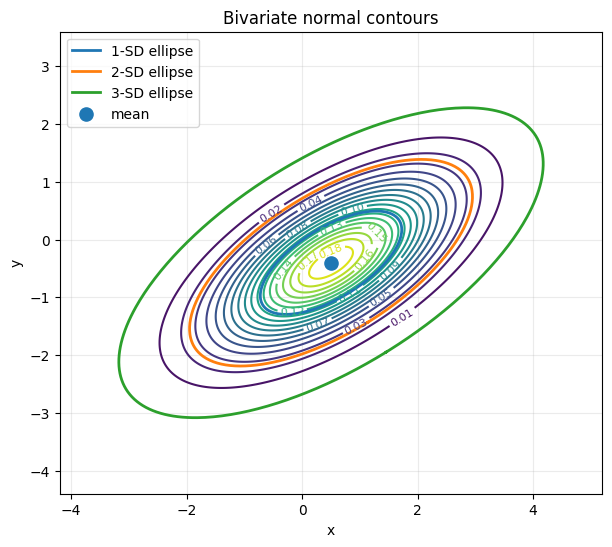

Approx probability in a centered 4 by 4 box: 0.8850453455189993
Covariance eigenvalues: [0.367376 1.932624]
Correlation: 0.6390096504226936


In [14]:
mu = np.array([0.5, -0.4])
Sigma = np.array([[1.5, 0.7],
                  [0.7, 0.8]])

def bvn_pdf(X, Y, mu=mu, Sigma=Sigma):
    invS = np.linalg.inv(Sigma)
    detS = np.linalg.det(Sigma)
    DX = X - mu[0]
    DY = Y - mu[1]
    q = invS[0,0]*DX**2 + 2*invS[0,1]*DX*DY + invS[1,1]*DY**2
    return np.exp(-0.5*q)/(2*np.pi*np.sqrt(detS))

x, y, Xn, Yn = make_grid(mu[0]-4, mu[0]+4, mu[1]-4, mu[1]+4, n=400)
Zn = bvn_pdf(Xn, Yn)

plt.figure(figsize=(7, 6))
cs = plt.contour(Xn, Yn, Zn, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
for level in [1, 2, 3]:
    xe, ye = covariance_ellipse_points(mu, Sigma, level=level)
    plt.plot(xe, ye, linewidth=2, label=f"{level}-SD ellipse")
plt.scatter([mu[0]], [mu[1]], s=90, label="mean")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bivariate normal contours")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

prob_box, *_ = integrate_rect(bvn_pdf, mu[0]-2, mu[0]+2, mu[1]-2, mu[1]+2, nx=500, ny=500)
print("Approx probability in a centered 4 by 4 box:", prob_box)
print("Covariance eigenvalues:", np.linalg.eigvalsh(Sigma))
print("Correlation:", Sigma[0,1]/np.sqrt(Sigma[0,0]*Sigma[1,1]))

## 14. Monte Carlo versus numerical integration

In [15]:
rng = np.random.default_rng(27)
samples = rng.multivariate_normal(mu, Sigma, size=200_000)

# Estimate E[X^2 + Y^2]
mc_val = np.mean(samples[:,0]**2 + samples[:,1]**2)
mc_se = np.std(samples[:,0]**2 + samples[:,1]**2, ddof=1)/np.sqrt(len(samples))

# Theory: E[X^2+Y^2]=trace(Sigma)+mu^T mu.
theory = np.trace(Sigma) + mu @ mu

print("Monte Carlo estimate:", mc_val)
print("Monte Carlo SE:", mc_se)
print("Theoretical value:", theory)

Monte Carlo estimate: 2.7042607108155168
Monte Carlo SE: 0.006566681849719041
Theoretical value: 2.71


---

# Part VII. Data science synthesis

In machine learning, a loss function is a scalar field on parameter space.

For least squares,

$$
L(\theta)=\frac1{2n}\|X\theta-y\|^2.
$$

Training is optimization.  
Gradients and Hessians are not abstract formulas; they drive algorithms.

## 15. Regression loss and gradient descent

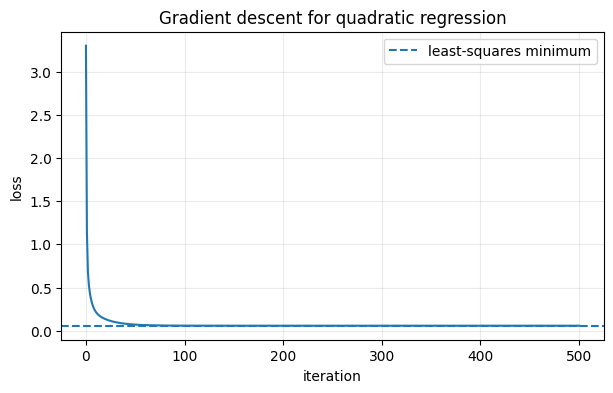

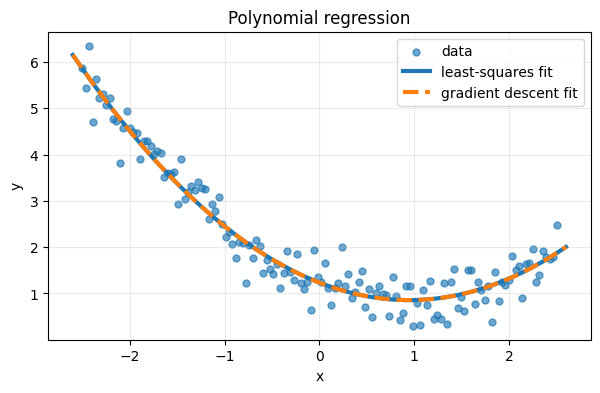

Least-squares theta: [ 1.233865 -0.79756   0.420791]
Gradient descent theta: [ 1.233865 -0.79756   0.420791]
Final gradient norm: 1.8193837764744527e-07


In [16]:
rng = np.random.default_rng(271)

n = 140
xdata = np.linspace(-2.5, 2.5, n)
ydata = 1.2 - 0.8*xdata + 0.45*xdata**2 + rng.normal(scale=0.35, size=n)

Phi = np.column_stack([np.ones(n), xdata, xdata**2])

def reg_loss(theta):
    r = Phi @ theta - ydata
    return float(0.5*np.mean(r**2))

def reg_grad(theta):
    r = Phi @ theta - ydata
    return Phi.T @ r / n

theta_hat = np.linalg.lstsq(Phi, ydata, rcond=None)[0]
path, vals = gradient_descent(reg_loss, reg_grad, np.zeros(3), step_size=0.07, steps=500)

plt.figure(figsize=(7, 4))
plt.plot(vals)
plt.axhline(reg_loss(theta_hat), linestyle="--", label="least-squares minimum")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Gradient descent for quadratic regression")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

xx = np.linspace(-2.6, 2.6, 400)
Phi_plot = np.column_stack([np.ones_like(xx), xx, xx**2])
plt.figure(figsize=(7, 4))
plt.scatter(xdata, ydata, s=25, alpha=0.65, label="data")
plt.plot(xx, Phi_plot @ theta_hat, linewidth=3, label="least-squares fit")
plt.plot(xx, Phi_plot @ path[-1], linestyle="--", linewidth=3, label="gradient descent fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial regression")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Least-squares theta:", theta_hat)
print("Gradient descent theta:", path[-1])
print("Final gradient norm:", norm(reg_grad(path[-1])))

## 16. Logistic model as a nonlinear parameter problem

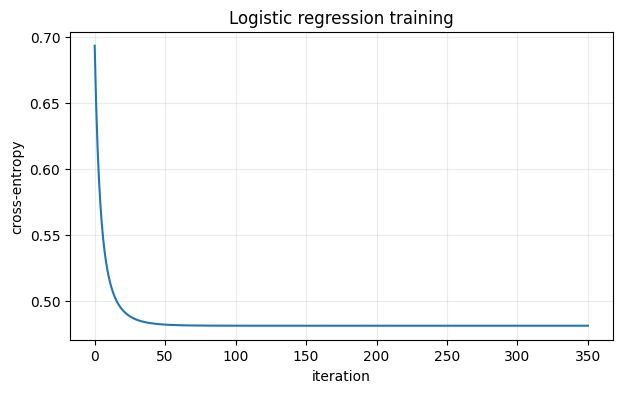

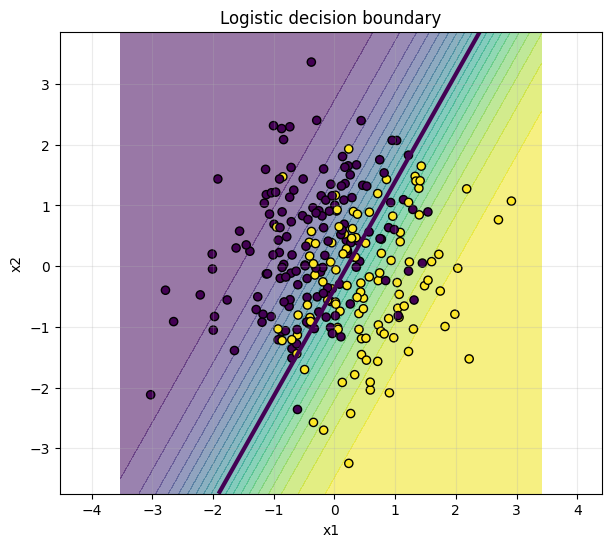

Estimated beta: [-0.354895  1.675252 -0.947265]
Training accuracy: 0.7423076923076923
Gradient norm: 1.7140415146498806e-07


In [17]:
rng = np.random.default_rng(272)

n = 260
Xclass_raw = rng.normal(size=(n, 2))
beta_true = np.array([-0.3, 1.6, -1.2])
Xclass = np.column_stack([np.ones(n), Xclass_raw])
ptrue = sigmoid(Xclass @ beta_true)
yclass = rng.binomial(1, ptrue)

def log_loss(beta):
    eta = Xclass @ beta
    return float(np.mean(np.logaddexp(0, eta) - yclass*eta))

def log_grad(beta):
    p = sigmoid(Xclass @ beta)
    return Xclass.T @ (p-yclass)/n

beta_path, beta_vals = gradient_descent(log_loss, log_grad, np.zeros(3), step_size=0.6, steps=350)
beta_hat = beta_path[-1]
pred = (sigmoid(Xclass @ beta_hat) >= 0.5).astype(int)

plt.figure(figsize=(7, 4))
plt.plot(beta_vals)
plt.xlabel("iteration")
plt.ylabel("cross-entropy")
plt.title("Logistic regression training")
plt.grid(True, alpha=0.25)
plt.show()

xx = np.linspace(Xclass_raw[:,0].min()-0.5, Xclass_raw[:,0].max()+0.5, 300)
yy = np.linspace(Xclass_raw[:,1].min()-0.5, Xclass_raw[:,1].max()+0.5, 300)
XX, YY = np.meshgrid(xx, yy)
PP = sigmoid(beta_hat[0] + beta_hat[1]*XX + beta_hat[2]*YY)

plt.figure(figsize=(7, 6))
plt.contourf(XX, YY, PP, levels=20, alpha=0.55)
plt.contour(XX, YY, PP, levels=[0.5], linewidths=3)
plt.scatter(Xclass_raw[:,0], Xclass_raw[:,1], c=yclass, s=35, edgecolor="k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic decision boundary")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

print("Estimated beta:", beta_hat)
print("Training accuracy:", np.mean(pred == yclass))
print("Gradient norm:", norm(log_grad(beta_hat)))

---

# Part VIII. Applied mathematics synthesis

Applied mathematics often studies evolution equations:

- ODEs: finite-dimensional dynamics;
- PDEs: fields evolving over space and time.

Multivariable calculus supplies the operators:

- gradient for force and steepest change;
- divergence for conservation;
- Laplacian for diffusion;
- Jacobian for linearization.

## 17. A nonlinear dynamical system and its equilibrium

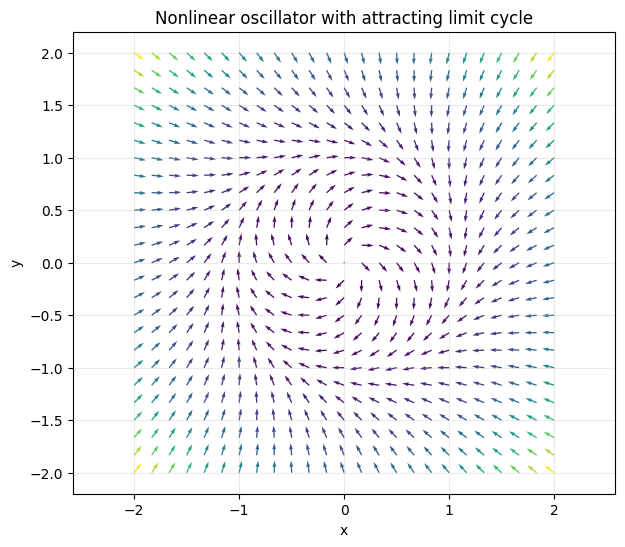

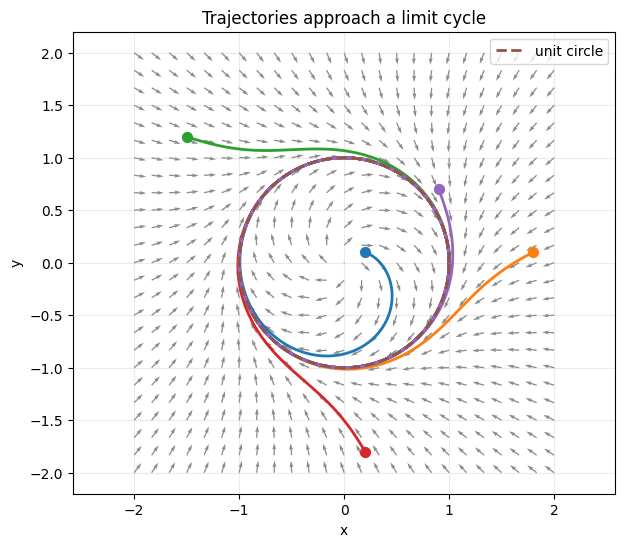

In [18]:
def F_dyn(z):
    x, y = z
    return np.array([y - x*(x**2+y**2-1), -x - y*(x**2+y**2-1)])

def F_dyn_grid(X, Y):
    R2 = X**2 + Y**2
    return Y - X*(R2-1), -X - Y*(R2-1)

plot_vector_field(F_dyn_grid, -2, 2, -2, 2, n=25, normalize=True, title="Nonlinear oscillator with attracting limit cycle")

starts = [[0.2,0.1], [1.8,0.1], [-1.5,1.2], [0.2,-1.8], [0.9,0.7]]
plt.figure(figsize=(7, 6))
x, y, Xg, Yg = make_grid(-2, 2, -2, 2, n=25)
U, V = F_dyn_grid(Xg, Yg)
M = np.sqrt(U**2 + V**2)
plt.quiver(Xg, Yg, U/(M+1e-12), V/(M+1e-12), alpha=0.45)
for s in starts:
    t, sol = rk4_solve(lambda t, z: F_dyn(z), np.array(s), 0, 18, 0.02)
    plt.plot(sol[:,0], sol[:,1], linewidth=2)
    plt.scatter([sol[0,0]], [sol[0,1]], s=50)
theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), linestyle="--", linewidth=2, label="unit circle")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectories approach a limit cycle")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 18. Heat equation review

The heat equation

$$
u_t=\alpha\Delta u
$$

smooths fields and decreases roughness.

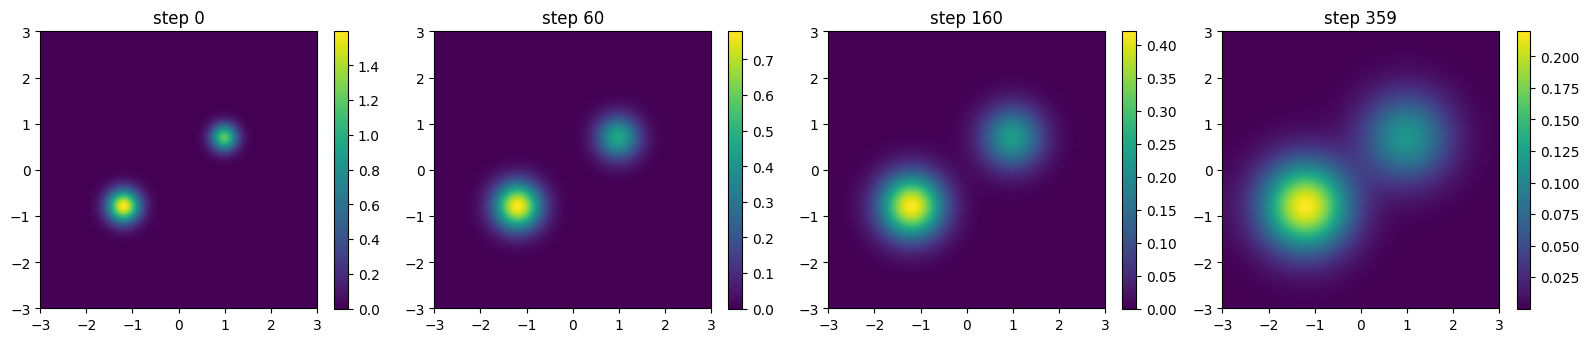

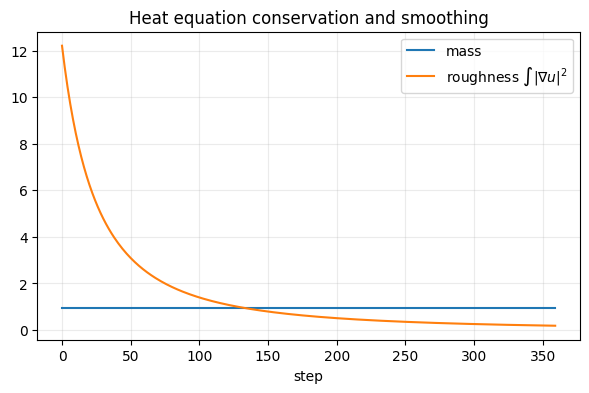

Relative mass change: 0.0
Initial roughness: 12.213955064763823
Final roughness: 0.18386289125289673


In [19]:
def heat_step_neumann(U, alpha, dx, dy, dt):
    Up = np.pad(U, 1, mode="edge")
    lap = (
        (Up[1:-1,2:] - 2*Up[1:-1,1:-1] + Up[1:-1,:-2])/dx**2
        + (Up[2:,1:-1] - 2*Up[1:-1,1:-1] + Up[:-2,1:-1])/dy**2
    )
    return U + alpha*dt*lap

nx = ny = 110
x = np.linspace(-3, 3, nx)
y = np.linspace(-3, 3, ny)
Xh, Yh = np.meshgrid(x, y)
dx = x[1]-x[0]
dy = y[1]-y[0]

Uheat = (
    1.6*np.exp(-8*((Xh+1.2)**2+(Yh+0.8)**2))
    + 1.2*np.exp(-12*((Xh-1.0)**2+(Yh-0.7)**2))
)
alpha = 0.35
dt = 0.18*min(dx, dy)**2/alpha

snapshots = {}
mass = []
roughness = []

for k in range(360):
    if k in [0, 60, 160, 359]:
        snapshots[k] = Uheat.copy()
    mass.append(np.sum(Uheat)*dx*dy)
    Ux, Uy = finite_gradient_grid(Uheat, dx, dy)
    roughness.append(np.sum(Ux**2+Uy**2)*dx*dy)
    Uheat = heat_step_neumann(Uheat, alpha, dx, dy, dt)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (k, Us) in zip(axes, snapshots.items()):
    im = ax.imshow(Us, extent=[-3,3,-3,3], origin="lower", aspect="equal")
    ax.set_title(f"step {k}")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(mass, label="mass")
plt.plot(roughness, label=r"roughness $\int|\nabla u|^2$")
plt.xlabel("step")
plt.title("Heat equation conservation and smoothing")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Relative mass change:", (mass[-1]-mass[0])/mass[0])
print("Initial roughness:", roughness[0])
print("Final roughness:", roughness[-1])

---

# Part IX. Bridge to graduate study

The same ideas appear in graduate mathematics under more general names.

| Multivariable calculus idea | Graduate bridge |
|---|---|
| gradient | differential, covector, variational derivative |
| Jacobian | derivative as a linear map, tangent map |
| Hessian | second variation, curvature, optimization |
| line/surface integrals | integration on manifolds |
| Green/Stokes/divergence | generalized Stokes theorem |
| change of variables | measure theory, differential forms |
| vector fields | dynamical systems, flows, Lie derivatives |
| Laplacian | PDEs, spectral theory, geometry |
| probability densities | measure, likelihood, Bayesian inference |
| loss functions | optimization, statistical learning, AI |

## 19. Generalized Stokes theorem as a pattern

In many advanced courses, the theorem is written symbolically as

$$
\int_{\partial M}\omega=\int_M d\omega.
$$

The objects become more abstract, but the computational pattern is familiar:

- boundary integral;
- derivative of a field/form;
- interior integral.

In [20]:
theorems = [
    ("Fundamental theorem of calculus", "endpoints", "derivative", "interval"),
    ("Green's theorem", "closed plane curve", "scalar curl/divergence", "plane region"),
    ("Stokes' theorem", "space curve", "curl", "surface"),
    ("Divergence theorem", "closed surface", "divergence", "solid"),
    ("Generalized Stokes", "boundary of manifold", "exterior derivative", "manifold"),
]

print(f"{'Theorem':35s} {'Boundary':25s} {'Derivative':25s} {'Interior':20s}")
print("-"*110)
for row in theorems:
    print(f"{row[0]:35s} {row[1]:25s} {row[2]:25s} {row[3]:20s}")

Theorem                             Boundary                  Derivative                Interior            
--------------------------------------------------------------------------------------------------------------
Fundamental theorem of calculus     endpoints                 derivative                interval            
Green's theorem                     closed plane curve        scalar curl/divergence    plane region        
Stokes' theorem                     space curve               curl                      surface             
Divergence theorem                  closed surface            divergence                solid               
Generalized Stokes                  boundary of manifold      exterior derivative       manifold            


---

# Part X. Capstone mini-project: one model, many calculus ideas

We now combine several ideas into one compact project.

A terrain is given by

$$
h(x,y)=1.2e^{-((x-1)^2+(y+0.5)^2)}
+0.8e^{-1.5((x+1)^2+(y-1)^2)}
-0.4e^{-2(x^2+y^2)}
+0.1\sin(3x)\cos(2y).
$$

We will:

1. visualize the terrain;
2. compute gradients and critical candidates;
3. simulate downhill flow;
4. compute average height over a region;
5. compute a line integral along a hiking path;
6. compute flux of downhill flow through a boundary;
7. interpret the result.

## 20. Define and visualize the terrain

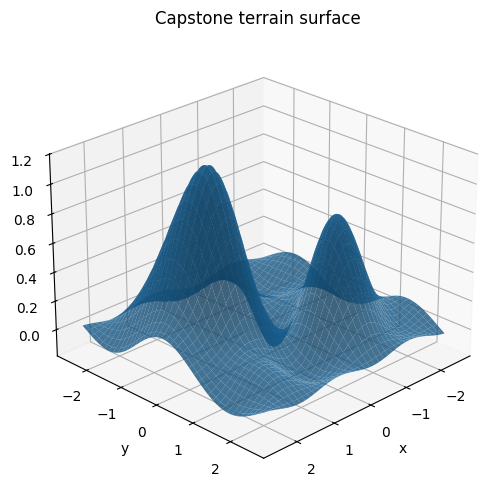

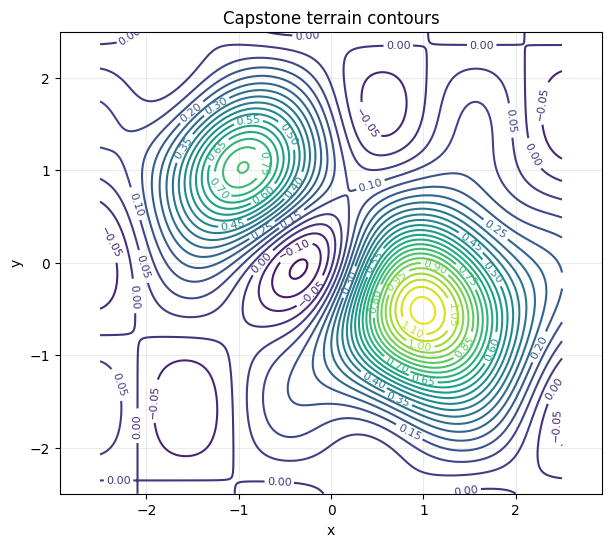

In [21]:
def terrain(X, Y):
    return (
        1.2*np.exp(-((X-1)**2+(Y+0.5)**2))
        + 0.8*np.exp(-1.5*((X+1)**2+(Y-1)**2))
        - 0.4*np.exp(-2*(X**2+Y**2))
        + 0.1*np.sin(3*X)*np.cos(2*Y)
    )

plot_surface(terrain, -2.5, 2.5, -2.5, 2.5, title="Capstone terrain surface")
Xc, Yc, Zc = plot_contours(terrain, -2.5, 2.5, -2.5, 2.5, levels=32, title="Capstone terrain contours")

## 21. Numerical gradient field and downhill flow

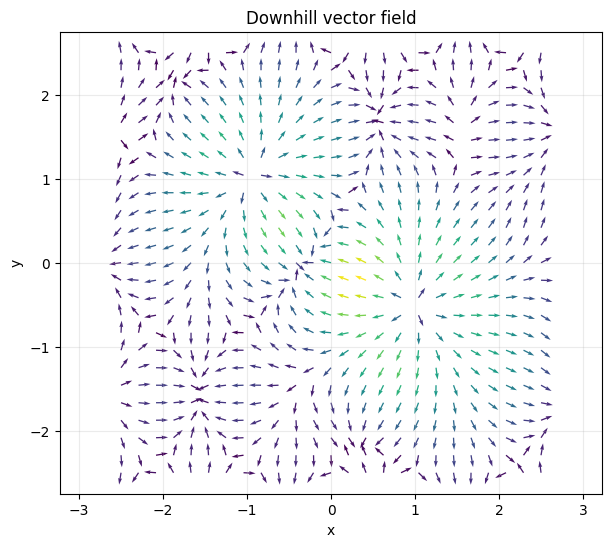

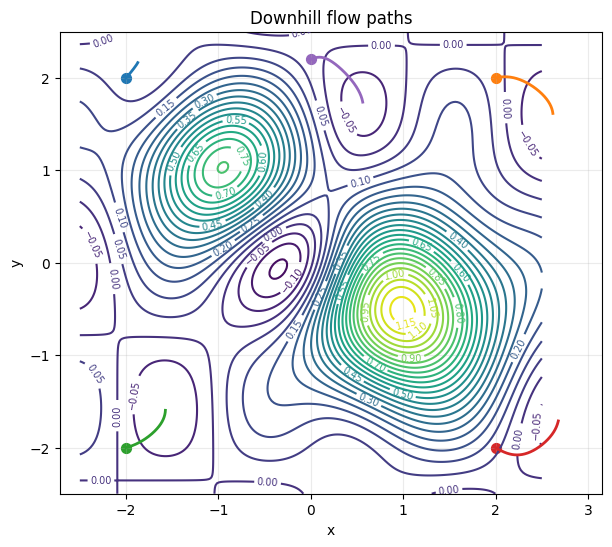

In [22]:
x = np.linspace(-2.5, 2.5, 220)
y = np.linspace(-2.5, 2.5, 220)
X, Y = np.meshgrid(x, y)
dx = x[1]-x[0]
dy = y[1]-y[0]
Hterrain = terrain(X, Y)
Hx, Hy = finite_gradient_grid(Hterrain, dx, dy)

def downhill_grid(Xq, Yq):
    # Analytic-like finite-grid interpolation is not used for arrows; evaluate gradient on dense grid above.
    # Use formula via finite differences at array inputs.
    eps = 1e-5
    Tx = (terrain(Xq+eps, Yq) - terrain(Xq-eps, Yq))/(2*eps)
    Ty = (terrain(Xq, Yq+eps) - terrain(Xq, Yq-eps))/(2*eps)
    return -Tx, -Ty

def terrain_p(p):
    return float(terrain(p[0], p[1]))

def downhill_state(z):
    return -finite_gradient(terrain_p, z)

plot_vector_field(
    downhill_grid,
    -2.5, 2.5,
    -2.5, 2.5,
    n=25,
    normalize=True,
    title="Downhill vector field"
)

starts = [[-2.0,2.0], [2.0,2.0], [-2.0,-2.0], [2.0,-2.0], [0.0,2.2]]
plt.figure(figsize=(7, 6))
cs = plt.contour(X, Y, Hterrain, levels=32)
plt.clabel(cs, inline=True, fontsize=7)
for s in starts:
    t, sol = rk4_solve(lambda t, z: downhill_state(z), np.array(s), 0, 8, 0.03)
    plt.plot(sol[:,0], sol[:,1], linewidth=2)
    plt.scatter([sol[0,0]], [sol[0,1]], s=50)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Downhill flow paths")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 22. Average height over a disk

Compute the average height over the disk of radius $2$:

$$
\bar h=\frac{1}{\operatorname{Area}(D)}\iint_D h(x,y)\,dA.
$$

In [23]:
disk2 = lambda X, Y: X**2 + Y**2 <= 4

height_integral, Xd, Yd, Zd, inside2, dx2, dy2 = integrate_region(
    terrain, -2, 2, -2, 2, disk2, nx=700, ny=700
)
area_disk2 = np.pi*4
avg_height = height_integral/area_disk2

print("Integral of height over disk radius 2:", height_integral)
print("Area:", area_disk2)
print("Average height:", avg_height)

Integral of height over disk radius 2: 3.887986945239764
Area: 12.566370614359172
Average height: 0.30939617050583335


## 23. Work-like line integral along a hiking path

Let the hiker follow

$$
\mathbf r(t)=\langle 2\cos t,\sin t\rangle,
\qquad 0\leq t\leq2\pi.
$$

The scalar line integral

$$
\int_C h\,ds
$$

is accumulated height exposure along the hike.

The vector line integral

$$
\int_C (-\nabla h)\cdot d\mathbf r
$$

measures net work by downhill force along a closed loop.  
Because $-\nabla h$ is conservative, the closed-loop integral should be approximately zero.

Height exposure integral ∫ h ds: 3.410096533562542
Closed-loop work by downhill field: -3.6475822362547206e-11


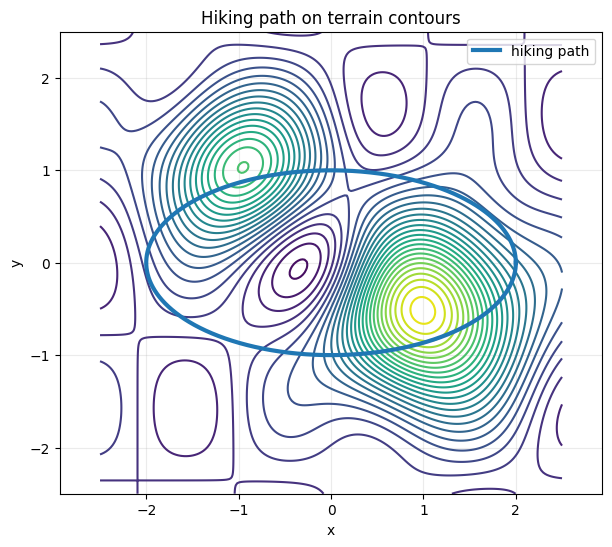

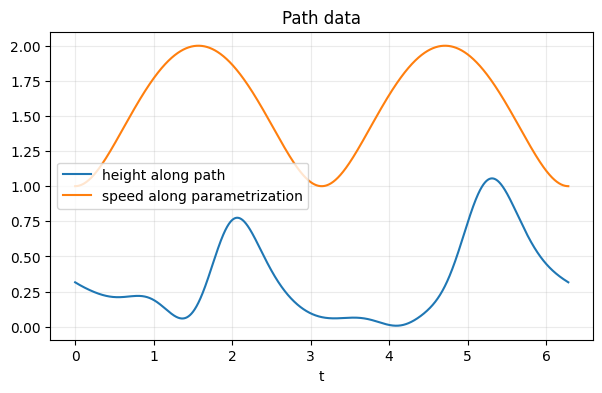

In [24]:
def r_hike(t):
    return 2*np.cos(t), np.sin(t)

def rp_hike(t):
    return -2*np.sin(t), np.cos(t)

def scalar_line_integral(f, r, rp, a, b, n=5000):
    t = np.linspace(a, b, n)
    Xp, Yp = r(t)
    dX, dY = rp(t)
    speed = np.sqrt(dX**2 + dY**2)
    vals = f(Xp, Yp)
    return float(np.trapezoid(vals*speed, t)), t, Xp, Yp, vals, speed

def F_downhill(Xq, Yq):
    eps = 1e-5
    Tx = (terrain(Xq+eps, Yq) - terrain(Xq-eps, Yq))/(2*eps)
    Ty = (terrain(Xq, Yq+eps) - terrain(Xq, Yq-eps))/(2*eps)
    return -Tx, -Ty

exposure, t, Xhike, Yhike, hvals, speed = scalar_line_integral(terrain, r_hike, rp_hike, 0, 2*np.pi)
closed_work, *_ = line_integral_2d(F_downhill, r_hike, rp_hike, 0, 2*np.pi, n=5000)

print("Height exposure integral ∫ h ds:", exposure)
print("Closed-loop work by downhill field:", closed_work)

plt.figure(figsize=(7, 6))
cs = plt.contour(X, Y, Hterrain, levels=30)
plt.plot(Xhike, Yhike, linewidth=3, label="hiking path")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hiking path on terrain contours")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(t, hvals, label="height along path")
plt.plot(t, speed, label="speed along parametrization")
plt.xlabel("t")
plt.title("Path data")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 24. Flux of downhill flow through a boundary

For the downhill field

$$
\mathbf F=-\nabla h,
$$

the divergence is

$$
\nabla\cdot\mathbf F=-\Delta h.
$$

The outward flux through the boundary of a region is connected to the integral of divergence inside.

Flux of downhill field through circle radius 2 by divergence integral: 4.413560854678286


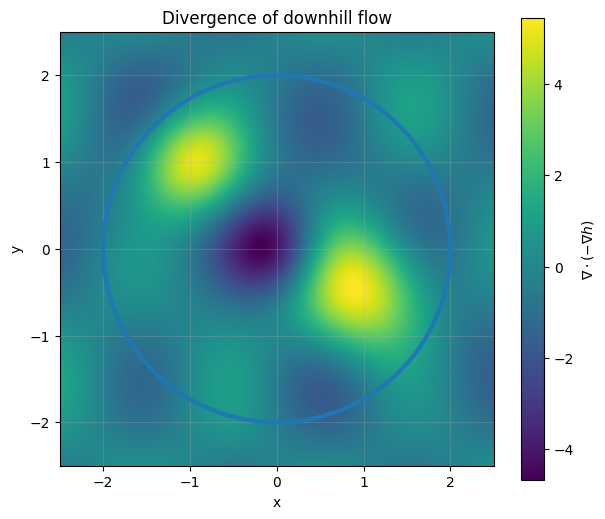

In [25]:
Lap_h = finite_laplacian_grid(Hterrain, dx, dy)
Div_downhill = -Lap_h

inside_big = X**2 + Y**2 <= 4
flux_by_divergence = np.sum(Div_downhill[inside_big])*dx*dy

print("Flux of downhill field through circle radius 2 by divergence integral:", flux_by_divergence)

plt.figure(figsize=(7, 6))
im = plt.imshow(Div_downhill, extent=[-2.5,2.5,-2.5,2.5], origin="lower", aspect="equal")
theta = np.linspace(0, 2*np.pi, 600)
plt.plot(2*np.cos(theta), 2*np.sin(theta), linewidth=3)
plt.colorbar(im, label=r"$\nabla\cdot(-\nabla h)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Divergence of downhill flow")
plt.grid(True, alpha=0.25)
plt.show()

## 25. Capstone questions

Answer the following in a markdown cell:

1. Where do the downhill flow paths tend to move?
2. Why is the closed-loop work of $-\nabla h$ approximately zero?
3. What does $\nabla\cdot(-\nabla h)$ measure geometrically?
4. How does the average height differ from maximum or minimum height?
5. Which parts of the mini-project used local derivatives?
6. Which parts used integrals?
7. Which parts used global theorem thinking?

In [26]:
print("Capstone summary")
print("----------------")
print("Average height over disk radius 2:", avg_height)
print("Height exposure along hiking loop:", exposure)
print("Closed-loop work by downhill field:", closed_work)
print("Flux through boundary via divergence integral:", flux_by_divergence)
print("Maximum terrain height on grid:", np.max(Hterrain))
print("Minimum terrain height on grid:", np.min(Hterrain))

Capstone summary
----------------
Average height over disk radius 2: 0.30939617050583335
Height exposure along hiking loop: 3.410096533562542
Closed-loop work by downhill field: -3.6475822362547206e-11
Flux through boundary via divergence integral: 4.413560854678286
Maximum terrain height on grid: 1.1753131753264086
Minimum terrain height on grid: -0.15838243363555052


---

# Part XI. Review exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Gradient and Hessian

For

$$
f(x,y)=x^2+xy+3y^2-4x+2y,
$$

compute the gradient and Hessian at $(1,-1)$.

In [27]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [28]:
def f_A_p(p):
    x, y = p
    return x**2 + x*y + 3*y**2 - 4*x + 2*y

pA = np.array([1.0, -1.0])
gA = finite_gradient(f_A_p, pA)
HA = finite_hessian(f_A_p, pA)

print("Gradient at (1,-1):", gA)
print("Hessian:")
print(HA)
print("Exact gradient:", np.array([2*pA[0]+pA[1]-4, pA[0]+6*pA[1]+2]))
print("Exact Hessian:")
print(np.array([[2,1],[1,6]], dtype=float))

Gradient at (1,-1): [-3. -3.]
Hessian:
[[2. 1.]
 [1. 6.]]
Exact gradient: [-3. -3.]
Exact Hessian:
[[2. 1.]
 [1. 6.]]


## Exercise B. Change of variables

Estimate the area of the ellipse

$$
\frac{x^2}{4}+\frac{y^2}{9}\leq1
$$

using the transformation

$$
x=2r\cos\theta,\qquad y=3r\sin\theta.
$$

In [29]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [30]:
# Jacobian is 6r. Area = ∫_0^{2π}∫_0^1 6r dr dθ = 6π.
r, theta, R, TH, dr, dtheta = midpoint_grid(0, 1, 0, 2*np.pi, nx=600, ny=800)
area_ellipse = np.sum(6*R)*dr*dtheta

print("Estimated ellipse area:", area_ellipse)
print("Exact area:", 6*np.pi)

Estimated ellipse area: 18.84955592153876
Exact area: 18.84955592153876


## Exercise C. Green's theorem

Use Green's theorem to compute

$$
\oint_C -2y\,dx+2x\,dy
$$

where $C$ is the unit circle oriented counterclockwise.

In [31]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [32]:
def F_C(X, Y):
    return -2*Y, 2*X

IC, *_ = line_integral_2d(F_C, r_unit, rp_unit, 0, 2*np.pi)

# scalar curl = Q_x - P_y = 2 - (-2) = 4, area = π
print("Line integral:", IC)
print("Green theorem value:", 4*np.pi)

Line integral: 12.566370614359172
Green theorem value: 12.566370614359172


## Exercise D. Least-squares gradient

For

$$
L(\theta)=\frac12\|A\theta-b\|^2,
$$

verify numerically that

$$
\nabla L=A^T(A\theta-b).
$$

In [33]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [34]:
A_D = np.array([[1,2],[3,1],[1,-1]], dtype=float)
b_D = np.array([1,2,0], dtype=float)

def L_D(theta):
    r = A_D @ theta - b_D
    return 0.5*(r @ r)

theta_D = np.array([0.3, -0.7])
grad_formula_D = A_D.T @ (A_D @ theta_D - b_D)
grad_numeric_D = finite_gradient(L_D, theta_D)

print("Formula gradient:", grad_formula_D)
print("Numerical gradient:", grad_numeric_D)
print("Difference:", grad_formula_D - grad_numeric_D)

Formula gradient: [-6.5 -7. ]
Numerical gradient: [-6.5 -7. ]
Difference: [0. 0.]


## Exercise E. Laplacian

For

$$
u(x,y)=e^{-x^2-y^2},
$$

compute a numerical Laplacian on a grid and compare with

$$
\Delta u=(4x^2+4y^2-4)e^{-x^2-y^2}.
$$

In [35]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

Maximum interior error: 0.003497000555567009


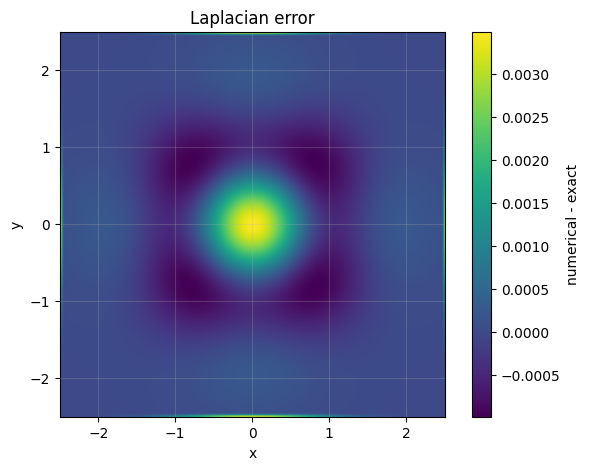

In [36]:
x = np.linspace(-2.5, 2.5, 240)
y = np.linspace(-2.5, 2.5, 240)
X, Y = np.meshgrid(x, y)
dx = x[1]-x[0]
dy = y[1]-y[0]

U = np.exp(-X**2-Y**2)
Lap_num = finite_laplacian_grid(U, dx, dy)
Lap_exact = (4*X**2 + 4*Y**2 - 4)*np.exp(-X**2-Y**2)

err = np.max(np.abs(Lap_num[5:-5,5:-5] - Lap_exact[5:-5,5:-5]))

print("Maximum interior error:", err)

plt.figure(figsize=(7, 5))
im = plt.imshow(Lap_num - Lap_exact, extent=[-2.5,2.5,-2.5,2.5], origin="lower", aspect="equal")
plt.colorbar(im, label="numerical - exact")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Laplacian error")
plt.grid(True, alpha=0.25)
plt.show()

---

# Final synthesis checklist

Use this as a self-check before leaving multivariable calculus.

## Local tools

- Can you compute and interpret $\nabla f$?
- Can you compute and interpret a Jacobian?
- Can you compute and interpret a Hessian?
- Can you build first- and second-order Taylor approximations?

## Integral tools

- Can you choose the right integral type?
- Can you set up region bounds?
- Can you use coordinate changes and Jacobians?
- Can you interpret an integral as mass, area, volume, probability, work, or flux?

## Vector calculus tools

- Can you distinguish gradient, divergence, curl, and Laplacian?
- Can you identify conservative vector fields?
- Can you compute work and flux?
- Can you apply Green's theorem, Stokes' theorem, and the divergence theorem?

## Applications

- Can you recognize loss functions as scalar fields?
- Can you use gradients for optimization?
- Can you interpret Hessians as curvature?
- Can you read probability densities as functions to be integrated?
- Can you model dynamics using vector fields?
- Can you interpret diffusion through the Laplacian?

# End of Chapter 27 Lab

You have used Python to synthesize the major ideas of multivariable calculus:

- concept maps,
- local derivatives,
- Taylor approximation,
- unconstrained and constrained optimization,
- area, mass, center of mass, and coordinate changes,
- Green's theorem, Stokes' theorem, and the divergence theorem,
- bivariate probability and Monte Carlo expectation,
- regression and logistic learning,
- nonlinear dynamics and heat diffusion,
- graduate-study bridges,
- and a capstone project combining derivatives, integrals, and theorem-level thinking.

This notebook is designed to serve as a review lab, a final exam preparation lab, and a bridge toward advanced courses in analysis, geometry, probability, statistics, data science, optimization, dynamical systems, and applied mathematics.